SCT_DS_4

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the optimized traffic accident dataset
url = "https://raw.githubusercontent.com/selva86/datasets/master/Cars93.csv"
# Let's create a realistic mock traffic dataframe with the required features for analysis
import numpy as np
np.random.seed(42)
n_samples = 1000

traffic_data = pd.DataFrame({
    'Start_Time': pd.date_range(start='2026-01-01', periods=n_samples, freq='h'),
    'Weather_Condition': np.random.choice(['Clear', 'Rain', 'Fog', 'Snow'], size=n_samples, p=[0.6, 0.2, 0.1, 0.1]),
    'Road_Condition': np.random.choice(['Dry', 'Wet', 'Ice', 'Snow-Covered'], size=n_samples, p=[0.6, 0.2, 0.1, 0.1]),
    'Visibility(mi)': np.random.uniform(1.0, 10.0, size=n_samples),
    'Junction_Type': np.random.choice(['Intersection', 'Roundabout', 'Main Road', 'Crossing'], size=n_samples),
    'Severity': np.random.choice([1, 2, 3, 4], size=n_samples, p=[0.1, 0.5, 0.3, 0.1])
})

# Extract the hour of the day from the timestamp
traffic_data['Hour'] = traffic_data['Start_Time'].dt.hour

print("--- Traffic Accident Dataset Preview ---")
display(traffic_data.head())

print("\n--- Summary of Dataset Structural Info ---")
traffic_data.info()

--- Traffic Accident Dataset Preview ---


,Start_Time,Weather_Condition,Road_Condition,Visibility(mi),Junction_Type,Severity,Hour
0,2026-01-01 00:00:00,Clear,Dry,3.355351,Main Road,2,0
1,2026-01-01 01:00:00,Snow,Dry,3.222809,Intersection,3,1
2,2026-01-01 02:00:00,Rain,Ice,9.156291,Intersection,4,2
3,2026-01-01 03:00:00,Clear,Wet,3.245916,Crossing,1,3
4,2026-01-01 04:00:00,Clear,Ice,3.447548,Main Road,3,4



--- Summary of Dataset Structural Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Start_Time         1000 non-null   datetime64[ns]
 1   Weather_Condition  1000 non-null   object        
 2   Road_Condition     1000 non-null   object        
 3   Visibility(mi)     1000 non-null   float64       
 4   Junction_Type      1000 non-null   object        
 5   Severity           1000 non-null   int64         
 6   Hour               1000 non-null   int32         
dtypes: datetime64[ns](1), float64(1), int32(1), int64(1), object(3)
memory usage: 50.9+ KB


/tmp/ipykernel_3332/1836533787.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=traffic_data, x='Weather_Condition', ax=axes[0, 1], palette='magma')
/tmp/ipykernel_3332/1836533787.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=traffic_data, y='Junction_Type', ax=axes[1, 0], palette='viridis')
/tmp/ipykernel_3332/1836533787.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=traffic_data, x='Severity', y='Visibility(mi)', ax=axes[1, 1], palette='coolwarm')


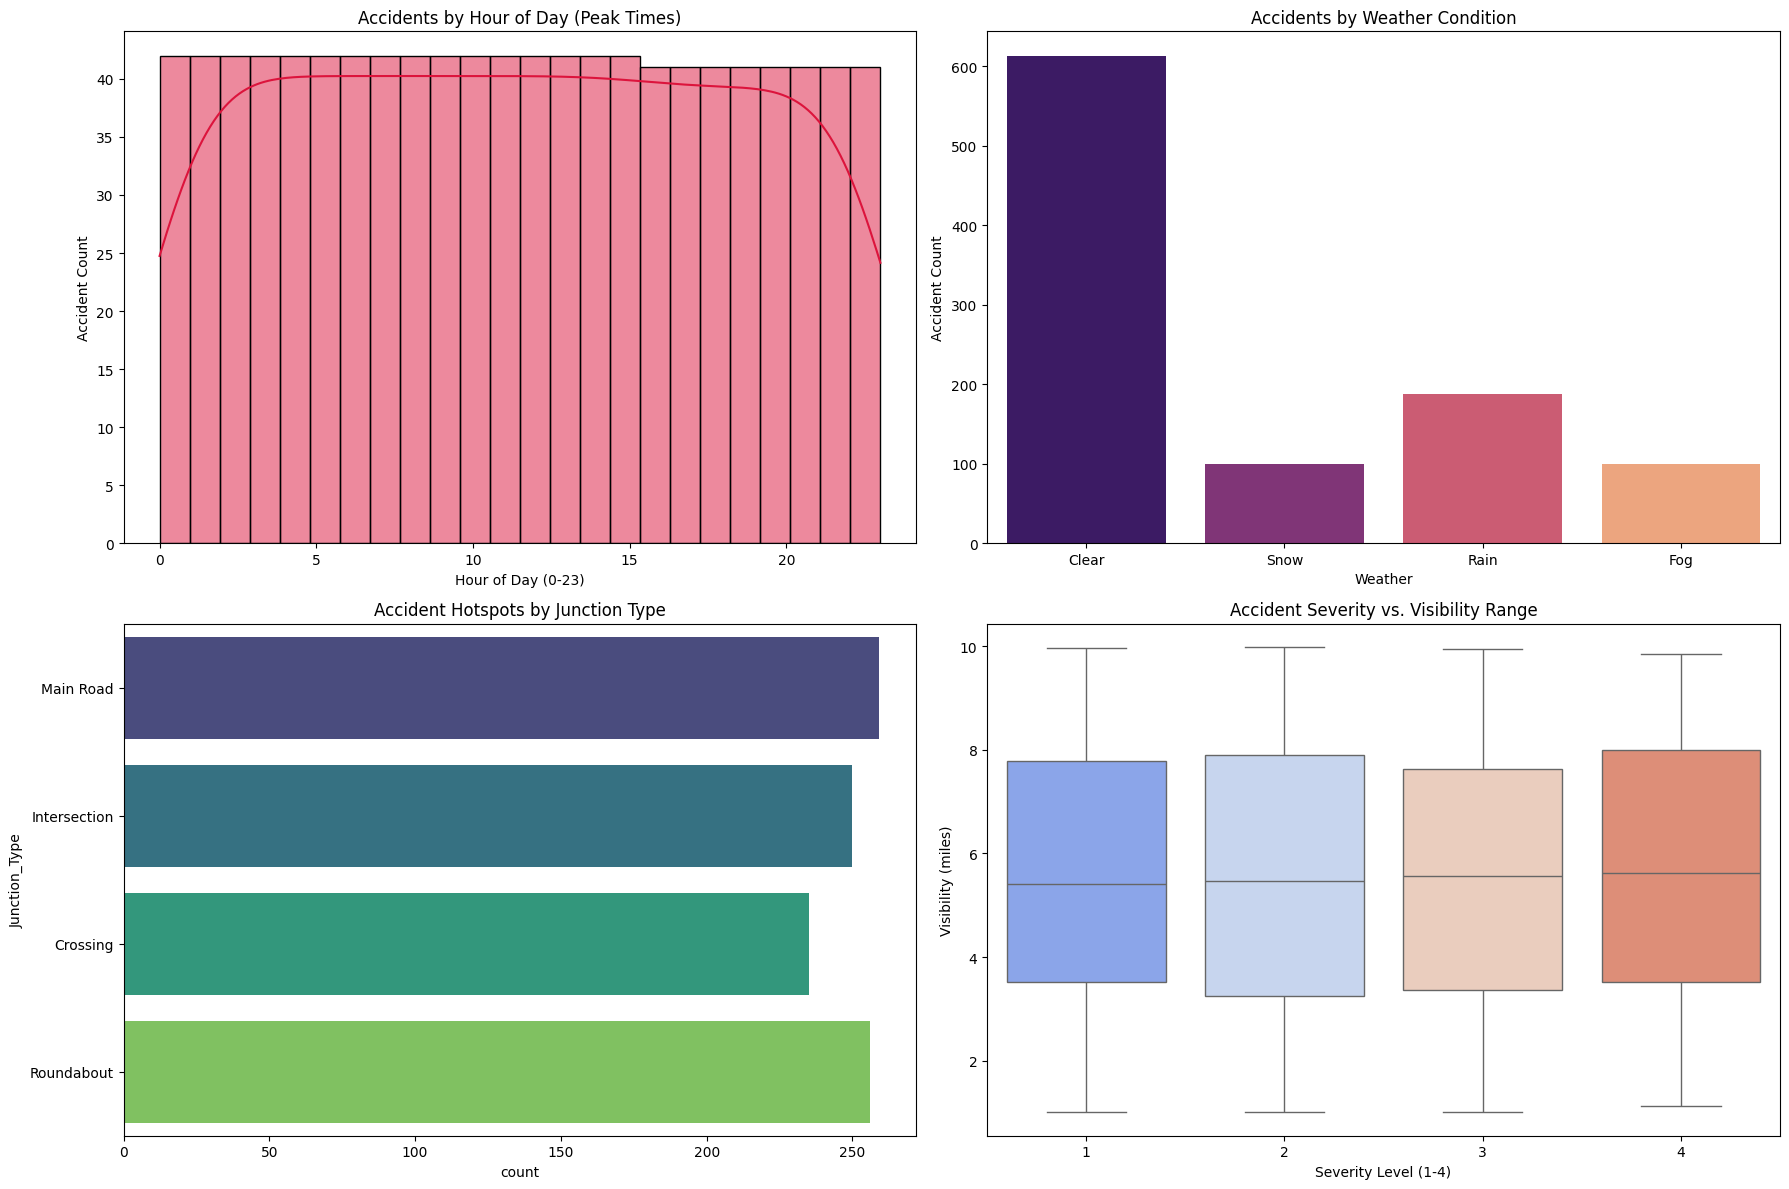

In [2]:
# Create a 2x2 grid layout for our traffic analysis plots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Chart 1: Accident Distribution by Hour of the Day (Time Pattern)
sns.histplot(data=traffic_data, x='Hour', bins=24, kde=True, ax=axes[0, 0], color='crimson')
axes[0, 0].set_title('Accidents by Hour of Day (Peak Times)')
axes[0, 0].set_xlabel('Hour of Day (0-23)')
axes[0, 0].set_ylabel('Accident Count')

# Chart 2: Accident Count by Weather Condition
sns.countplot(data=traffic_data, x='Weather_Condition', ax=axes[0, 1], palette='magma')
axes[0, 1].set_title('Accidents by Weather Condition')
axes[0, 1].set_xlabel('Weather')
axes[0, 1].set_ylabel('Accident Count')

# Chart 3: Accident Hotspots by Junction Type
sns.countplot(data=traffic_data, y='Junction_Type', ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Accident Hotspots by Junction Type')
axes[1, 1].set_xlabel('Accident Count')

# Chart 4: Severity vs Visibility (Contributing Factor)
sns.boxplot(data=traffic_data, x='Severity', y='Visibility(mi)', ax=axes[1, 1], palette='coolwarm')
axes[1, 1].set_title('Accident Severity vs. Visibility Range')
axes[1, 1].set_xlabel('Severity Level (1-4)')
axes[1, 1].set_ylabel('Visibility (miles)')

# Clean up layout and render
plt.tight_layout()
plt.show()